In [1]:
# Generelle moduler og funksjonsbeskrivelser brukt i forelesningen
from numpy import sin, cos, pi, exp, angle, abs, unwrap, log10
import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt
from IPython.display import Audio

plt.rcParams["figure.figsize"] = [8.00, 4.5]
plt.rcParams["figure.autolayout"] = True
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.xmargin"] = 0.0

%matplotlib inline

# Enable importing from modules in top-level directory
from sys import path
if path[0] != '..': path.insert(0, '..')

<img src="figurer/NTNU_logo_vertical.svg" align="left" width="30%">
<br clear="all" />
<br></br>

# Sampling og Rekonstruksjon

* **Emne: AIS2102 - Dynamiske system**
* ***dato***: 12. januar 2026
* **Foreleser: Kai Erik Hoff**

# Tema:

* <font color="d62728">Uniform Sampling (A/D omforming)</font>
* Rekonstruksjon (D/A omforming)

# Sampling (A/D omforming)

* Signalet representeres som en serie med måleverdier.
* Oppnås ved å ta gjentatte punktprøver.
    * På f.eks. en Arduino utføres dette med gjentatte kall til funksjonen `analogRead()`.
* Denne prosessen er kjent som sampling.

<div style="width: 90%;">
    <img src="figurer/Fig5_DigitalSig.png" style="float: left; width: 45%" />
    <div style="float: right; width: 45%">
    <br>
        <b>Notasjon</b>:
        $$u[k],  \ u(k) \text{ eller } u_k$$
    <ul>
        <li><i>Temperatursignalet i figuren er en "tidsdiskret" funksjon av samplenummer 
            </i> $k \in \mathbb{Z}$.</li>
        <li>Bokstavene $l$, $m$ og $n$ er ofte også designert som heltallsvariabler i konteksten av diskréte tallrekker</li>
    </ul>  
    </div>
</div> 

# Sampletid $T_s$

* Samplene ***må*** tas med **jevne tidsintervall**.
    * Forutsetningen for vellykket diskretisering.
* Sampletiden $T_s$ lik tidsintervallet fra én måling til neste.
<br><br>
<img src="figurer/Fig9_Ts.png" style="width: 80%; margin-left: 100px" />

# Samplingsfrekvens $f_s$

* ***Antallet*** sampler som tas i løpet av ett sekund.
* Sampletid og sampleperiode:
$$f_s = \frac{1}{T_s}$$
* Sammenheng mellom måletidspunkt $t_k$ og samplenummer $k$:
$$t = k\cdot T_s = \frac{k}{f_s}$$
$$k = \frac{t}{T_s} = t\cdot f_s$$

# Matematisk modell A/D omformer 

* Sammenheng mellom analogt og tigitalt signal ved idéell sampling:

$$\Large u[k] = u(t) \bigg|_{t=k\cdot T_s}$$



<img src="figurer/sampling_1.png" style="width: 60%; margin-left: 20%" />

# Normalisert frekvens $\hat{f}$

* Frekvensanalyse av diskrete signal/system bruker av og til *normalisert frekvens*
    - Tillater analyse av tidsdiskrete system $G(z)$ uavhengig av samplingsfrekvens $f_s$.
    

$$\Large \hat{f} = \frac{f}{f_s}$$

# Regneeksempel:

1. Et signal $u(t) = \cos \left( 12\pi \cdot t\right) $ samples med $f_s = 20$ målinger i sekundet. Hva blir funksjonsuttrykket til det samplede signalet $u[k]$?
2. Hva er den normaliserte frekvensen til $u[k]$?

## Regneeksempel illustrert

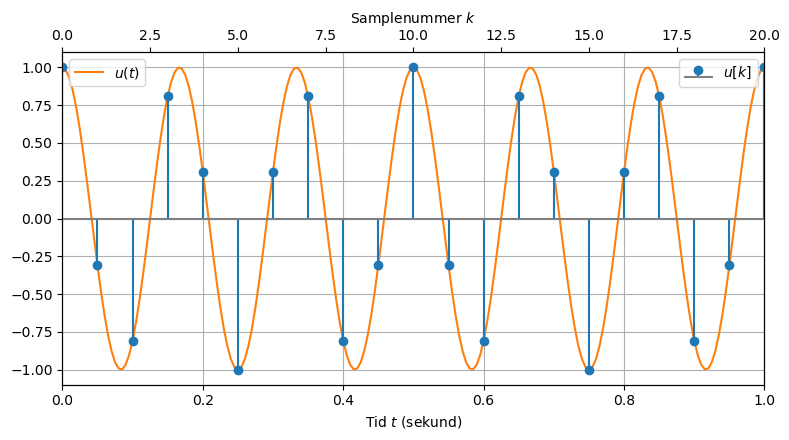

In [5]:

# Funksjonsuttrykk for u(t)
def u(t):
    return cos(12*pi*t)

# Høyoppløselig tids-array for å illustrere "continuous-time"
T = 1.0
t = np.linspace(0, T, 201)

# Plotting av tidskontinuerlig signal
plt.plot(t, u(t), "C1", label="$u(t)$")
plt.xlabel("Tid $t$ (sekund)")
plt.legend(loc="upper left")

# Tidsdiskret signal
fs = 20 # Samplingsfrekvens
k = np.arange(int(T*Fs)+1)  # sample-indekser

plt.twiny(); plt.grid(False) # Lag x-akse for samplenummer fremfor sekund
plt.stem(k, u(k/fs), label="$u[k]$", basefmt="grey")
plt.xlabel("Samplenummer $k$")
plt.legend(loc="upper right")
plt.show()

# Oppsummering av viktige begreper

* Samplingsfrekvens $f_s$: antallet sampler/målinger per sekund
    * Konstant parameter for et tidsdiskret system
* Samplingsperiode $T_s$: antall sekund mellom hver sample
$$T_s = \frac{1}{f_s}$$

* Tidsdiskret signal $u[k]$:
$$ u[k] = u(t) \big|_{t = k\cdot T_s}$$

* Normalisert frekvens: antallet svinginger i et signal *per sample*
\begin{align}
\hat{f} &= \frac{f}{f_s} \\
\hat{\omega} &= \frac{\omega}{f_s} = 2\pi \cdot \hat{f}
\end{align}

# Tema:

* Uniform Sampling (A/D omforming)
* <font color="d62728">Rekonstruksjon (D/A omforming)</font>

# Rekonstruksjon av én sample


* Mange metoder for D/A omforming
    - Alle omhandler å erstatte en sample med en pulsform
    
    
* **Zero Order Hold** (ZOH) mest vanlig i digital reguleringsteknikk
    - Hver sample erstattes med en rektangulær puls med bredde $T_s$.
    
    
<img src="figurer/zoh_1.png" style="width: 80%; margin-left: 10%" />

# Rekonstruksjon av signal

* "Zero order hold" resulterer i et trappeformet utgangssignal $\bar{u}(t)$.
    - Betyr i praksis "sett utgangsspenningen lik nåværende sampleverdi $u[k]$, og la stå til det kommer nye instruksjoner".
    
<img src="figurer/zoh_2.png" style="width: 70%; margin-left: 10%" />

# Effekten av ZOH

* $\bar{u}(t)$ henger "i gjennomsnitt" $\frac{T_s}{2}$ sekund etter $y(t)$<br><img src="figurer/zoh_3.png" style="width: 70%; margin-left: 10%" /><br>
    * *Kantene "jevnes ut" av fysisk prossess (lavpass-egenskaper)*

# Modellering av ZOH i regulatordesign

* Den ekstra tidsforsinkelsen tas med i design av regulator
    * Vil påvirke f.eks. gain- og fasemargin
    
<img src="figurer/zoh_4.png" style="width: 90%" /><br>

# Frekvensanalyse av ZOH

* Vi tar for oss open-loop analyse av diskret regulator der $G_c(z) = 1$ ($K_p=1$, $K_i=0$, $K_d=0$ for PID):

<img src="figurer/zoh_5.png" style="width: 90%" /><br>

$$
\begin{align}
\text{Gain} &= \left| e^{-j\omega \cdot \frac{T_s}{2}} \right| = 1\\
\text{Phase} &= \angle e^{-j\omega\cdot \frac{T_s}{2}} = -j\omega\cdot \frac{T_s}{2}
\end{align}
$$

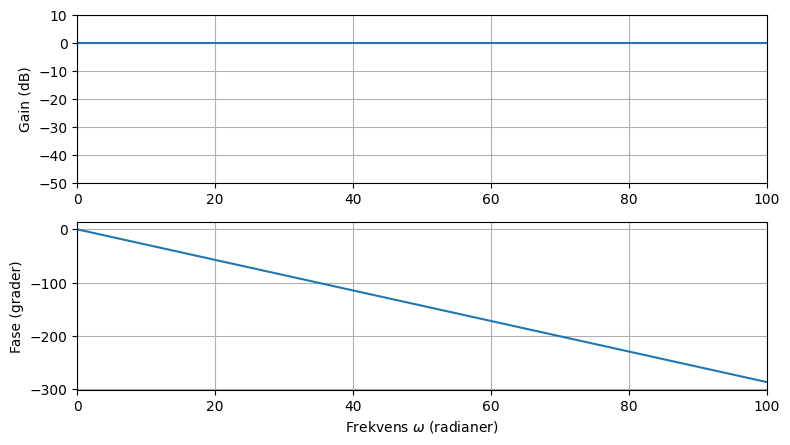

In [7]:
# Sett sampletiden
Ts = 0.1 # Sekund

# Regn ut transferfunksjon for ZOH rekonstruksjon
w = np.linspace(0, 100, 101) # Vinkelfrekvens
s = 0 + 1j*w # Array med verdier av 's' langs frekvensaksen
G_zoh = lambda s: exp(-s*Ts/2) # Transferfunksjon G_zoh(s)

# Regner ut bode-pot 'manuelt', da G_zoh(s) ikke kan uttrykkes som en "vanlig" transferfunksjon
phase = unwrap(angle(G_zoh(s), deg=True), period=360)  # Fase i grader
gain = 20*log10(abs(G_zoh(s)))  # gain i dB

plt.close(3); plt.figure(3);
plt.subplot(2,1,1)
plt.plot(w, gain)
plt.ylim([-50, 10])
plt.ylabel("Gain (dB)")
plt.subplot(2,1,2)
plt.plot(w, phase)
plt.ylabel("Fase (grader)")
plt.xlabel("Frekvens $\\omega$ (radianer)")
plt.tight_layout()
plt.show()

# Kodeeksempel:

* Gitt et system $G(s) = \frac{1}{s(s+1)}$.
    - Studer effekten av ulike forsinkelser på bode-plottet til det totale systemet.
    
<img src="figurer/delay_1.png" style="width: 60%" /><br>

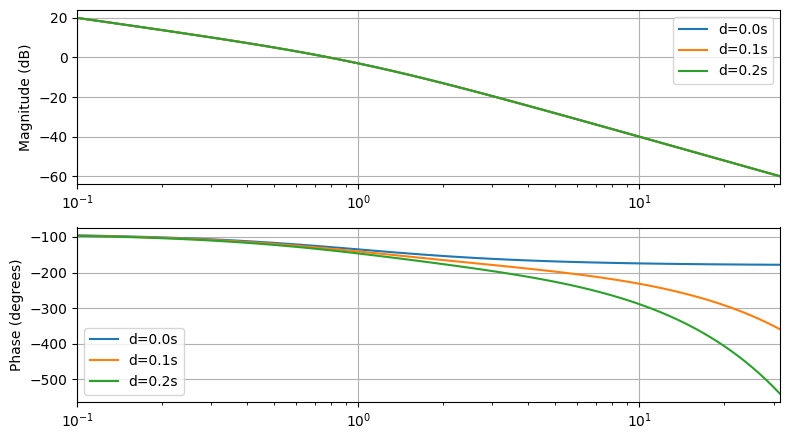

In [10]:
G = sig.TransferFunction([1],[1,1,0]) # Lag transferfunksjon for systemet G(s)

d_vals = [0.0, 0.1, 0.2] # Tidsforsinkelser

w = np.logspace(-1, 1.5, 101)  # vinkelfrekvens omega

w, mag, phase = sig.bode(G, w=w)

fig, [ax1, ax2] = plt.subplots(2, 1)
for d in d_vals:
    ax1.semilogx(w, mag, label="d=%.1fs"%(d))

    ax2.semilogx(w, phase-np.rad2deg(w*d), label="d=%.1fs"%(d))
ax1.set_ylabel("Magnitude (dB)")
ax1.legend()
ax2.set_ylabel("Phase (degrees)")
ax2.legend()
plt.show()

#### Alternativ MATLAB-kode:

```octave
s = tf('s');

G = 1/(s*(s+1));

d = [0.0, 0.1, 0.2]; % Sekund delay


figure();
opt = bodeoptions;
opt.FreqScale = 'Linear';
hold on;
for i = 1:length(d)
    bode(exp(-s*d(i)), opt)
end
ylim([-360, 0]);
hold off;
legend({'d=0.1', 'd=0.2', 'd=0.4'})
grid();
```

# Bode-plot og ZOH

* Vi ser på hvordan ZOH påvirker bode-plottet til en open-loop regulator $G_c(s)$
    - Vi antar "ideell" diskretisering

<img src="figurer/zoh_6.png" style="width: 80%" /><br>

# Prosesseringstid



* En annen kilde til forsinkelse i digitale regulatorer
    * Tiden prosessoren bruker til å utføre alle regneoperasjoner påkrevd for én oppdatering av utgangsverdien $y[k]$
    * Vi regner typisk med at forsinkelsen fra prosessering er mindre enn én sampleperiode
$$\text{prosesseringstid} < T_s$$
        * Dersom prosesseringstid er større enn $T_s$, kan man forvente uforutsigbare sampletidspunkt.


* Samlet forsinkelse i et tidsdiskret system:
$$\frac{T_s}{2}<d<\frac{3T_s}{2}$$

# Eksempel på realisering

<img src="figurer/implementation_1.png" style="width: 80%" /><br>